# **Edge Detectuon**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Position (1,1)
Region: 
[[10. 10. 10.]
 [10. 10. 10.]
 [10. 10. 10.]]
GX =  0.0
Gy =  0.0
Gradient magnitude =  0.0

Position (1,2)
Region: 
[[10. 10. 10.]
 [10. 10. 10.]
 [10. 10. 10.]]
GX =  0.0
Gy =  0.0
Gradient magnitude =  0.0

Position (1,3)
Region: 
[[10. 10. 10.]
 [10. 10. 10.]
 [10. 10. 10.]]
GX =  0.0
Gy =  0.0
Gradient magnitude =  0.0

Position (2,1)
Region: 
[[ 10.  10.  10.]
 [ 10.  10.  10.]
 [200. 200. 200.]]
GX =  760.0
Gy =  760.0
Gradient magnitude =  1074.8023074035523

Position (2,2)
Region: 
[[ 10.  10.  10.]
 [ 10.  10.  10.]
 [200. 200. 200.]]
GX =  760.0
Gy =  760.0
Gradient magnitude =  1074.8023074035523

Position (2,3)
Region: 
[[ 10.  10.  10.]
 [ 10.  10.  10.]
 [200. 200. 200.]]
GX =  760.0
Gy =  760.0
Gradient magnitude =  1074.8023074035523

Position (3,1)
Region: 
[[ 10.  10.  10.]
 [200. 200. 200.]
 [200. 200. 200.]]
GX =  760.0
Gy =  760.0
Gradient magnitude =  1074.8023074035523

Position (3,2)
Region: 
[[ 10.  10.  10.]
 [200. 200. 200.]
 [200. 20

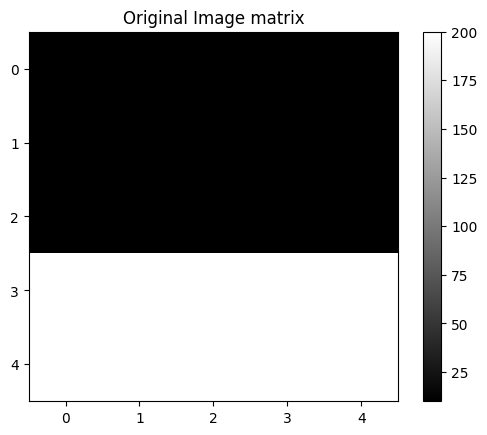

Final Gradient Magnitude Matrix:
[[   0.           0.           0.       ]
 [1074.8023074 1074.8023074 1074.8023074]
 [1074.8023074 1074.8023074 1074.8023074]]


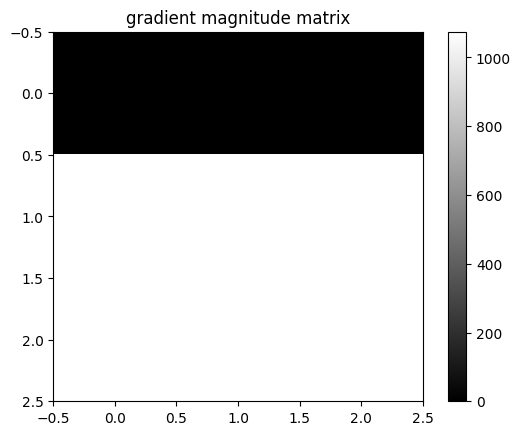


Thresholded Edge Map (T=100):
[[0. 0. 0.]
 [1. 1. 1.]
 [1. 1. 1.]]


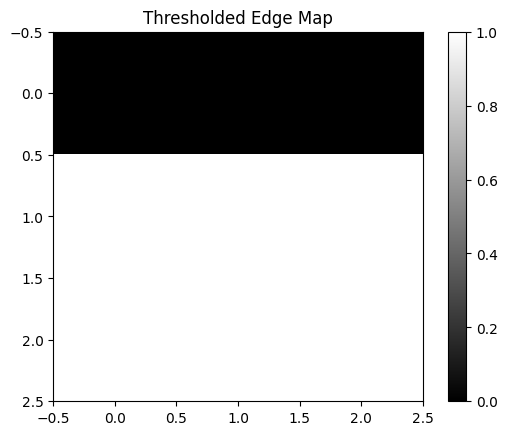

In [2]:
#? giving 5*5 Matrix
image = np.array([
[10,10,10,10,10],
[10,10,10,10,10],
[10,10,10,10,10],
[200,200,200,200,200],
[200,200,200,200,200]
], dtype=np.float32)


#? sobal kernal
Gx = np.array([
[-1,-2,-1],
[ 0, 0, 0],
[ 1, 2, 1]
])

Gy = np.array([
[ 1, 0,-1],
[ 2, 0,-2],
[ 1, 0,-1]
])

#? Output matrix (3*3)
output = np.zeros((3,3))

#? loop through each internal position
for i in range (1,4):
    for j in range (1,4):
        #? extract 3*3 region 
        region = image[i-1:i+2,j-1:j+2]
        #? calculate gradients
        gx = np.sum(region*Gx)
        gy = np.sum(region*Gx)
        #? grasient magnitude
        magnitude = np.sqrt(gx**2 + gy**2)

        output[i-1,j-1] = magnitude 

        print(f"Position ({i},{j})")
        print("Region: ")
        print(region)
        print("GX = ",gx)
        print("Gy = ",gy)
        print("Gradient magnitude = ",magnitude)
        print()

T = 100

#? Output matrices
gradient = np.zeros((3,3))
edge_map = np.zeros((3,3))

#? Loop through internal pixels
for i in range(1,4):
    for j in range(1,4):

        #? Extract 3x3 region
        region = image[i-1:i+2, j-1:j+2]

        #? Calculate gradients
        gx = np.sum(region * Gx)
        gy = np.sum(region * Gy)

        #? Gradient magnitude
        magnitude = np.sqrt(gx**2 + gy**2)

        gradient[i-1,j-1] = magnitude

        #? Apply Threshold
        if magnitude >= T:
            edge_map[i-1,j-1] = 1
        else:
            edge_map[i-1,j-1] = 0

        print(f"Position ({i},{j}) -> Gradient = {magnitude}, Edge = {edge_map[i-1,j-1]}")

         

print(image) 
plt.imshow(image, cmap='gray')
plt.title('Original Image matrix')
plt.colorbar()
plt.show()   
print("Final Gradient Magnitude Matrix:")
print(output)
plt.imshow(output, cmap='gray')
plt.title('gradient magnitude matrix')
plt.colorbar()
plt.show()
print("\nThresholded Edge Map (T=100):" )
print(edge_map)
plt.imshow(edge_map, cmap='gray')
plt.title('Thresholded Edge Map')
plt.colorbar()
plt.show()  

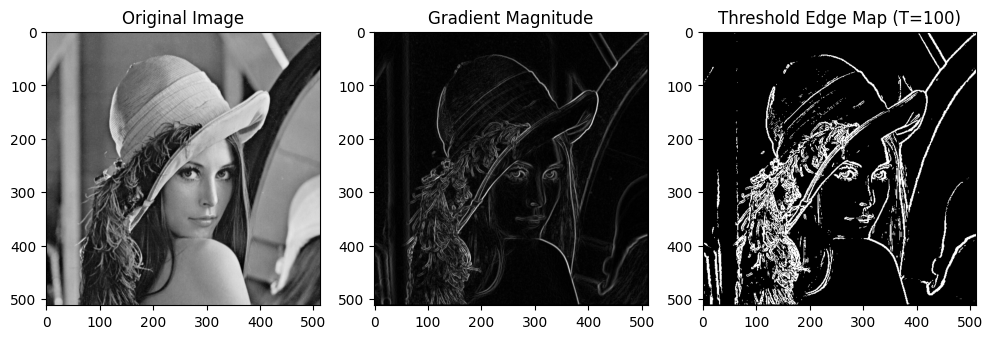

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Read image
image = cv2.imread(r"C:\BDA\digital image processing\Dip_class\dip_img\lena_image.png")

# Convert to grayscale
image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Sobel kernels
Gx = np.array([
[-1,-2,-1],
[0,0,0],
[1,2,1]
])

Gy = np.array([
[1,0,-1],
[2,0,-2],
[1,0,-1]
])

T = 100

rows, cols = image.shape

gradient = np.zeros((rows,cols))
edge_map = np.zeros((rows,cols))

# Loop through image
for i in range(1,rows-1):
    for j in range(1,cols-1):

        region = image[i-1:i+2, j-1:j+2]

        gx = np.sum(region * Gx)
        gy = np.sum(region * Gy)

        magnitude = np.sqrt(gx**2 + gy**2)

        gradient[i,j] = magnitude

        # Apply threshold
        if magnitude >= T:
            edge_map[i,j] = 1
        else:
            edge_map[i,j] = 0

# Show results
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")

plt.subplot(1,3,2)
plt.imshow(gradient, cmap='gray')
plt.title("Gradient Magnitude")

plt.subplot(1,3,3)
plt.imshow(edge_map, cmap='gray')
plt.title("Threshold Edge Map (T=100)")

plt.show()

# **Sobal Operator(without padding)**

In [4]:
import numpy as np

In [5]:
# Input image
arr = np.array([
              [10,10,10,10,10],
              [10,10,10,10,10],
              [10,10,10,10,10],
              [200,200,200,200,200],
              [200,200,200,200,200]
              ])

In [6]:
# Define the 3x3 Sobel kernels
Kx = np.array([[-1, 0, 1],
                   [-2, 0, 2],
                   [-1, 0, 1]])

Ky = np.array([[-1, -2, -1],
                   [ 0,  0,  0],
                   [ 1,  2,  1]])

In [7]:
height, width = arr.shape
out_height, out_width = height - 2, width - 2

In [8]:
# Initialize output arrays
Gx = np.zeros((out_height, out_width))
Gy = np.zeros((out_height, out_width))

In [9]:
magnitude = np.zeros((out_height, out_width))

# Now your loops will work perfectly:
for i in range(out_height):
    for j in range(out_width):
        region = arr[i:i+3, j:j+3]
        print(region,"\n")

        gx = np.sum(region * Kx)
        gy = np.sum(region * Ky)
        
        
        # Calculate magnitude (This now works because magnitude is a grid)
        magnitude[i, j] = np.sqrt(gx**2 + gy**2)
        print(magnitude,"\n")

[[10 10 10]
 [10 10 10]
 [10 10 10]] 

[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]] 

[[10 10 10]
 [10 10 10]
 [10 10 10]] 

[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]] 

[[10 10 10]
 [10 10 10]
 [10 10 10]] 

[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]] 

[[ 10  10  10]
 [ 10  10  10]
 [200 200 200]] 

[[  0.   0.   0.]
 [760.   0.   0.]
 [  0.   0.   0.]] 

[[ 10  10  10]
 [ 10  10  10]
 [200 200 200]] 

[[  0.   0.   0.]
 [760. 760.   0.]
 [  0.   0.   0.]] 

[[ 10  10  10]
 [ 10  10  10]
 [200 200 200]] 

[[  0.   0.   0.]
 [760. 760. 760.]
 [  0.   0.   0.]] 

[[ 10  10  10]
 [200 200 200]
 [200 200 200]] 

[[  0.   0.   0.]
 [760. 760. 760.]
 [760.   0.   0.]] 

[[ 10  10  10]
 [200 200 200]
 [200 200 200]] 

[[  0.   0.   0.]
 [760. 760. 760.]
 [760. 760.   0.]] 

[[ 10  10  10]
 [200 200 200]
 [200 200 200]] 

[[  0.   0.   0.]
 [760. 760. 760.]
 [760. 760. 760.]] 



[[ 10  10  10  10  10]
 [ 10  10  10  10  10]
 [ 10  10  10  10  10]
 [200 200 200 200 200]
 [200 200 200 200 200]]


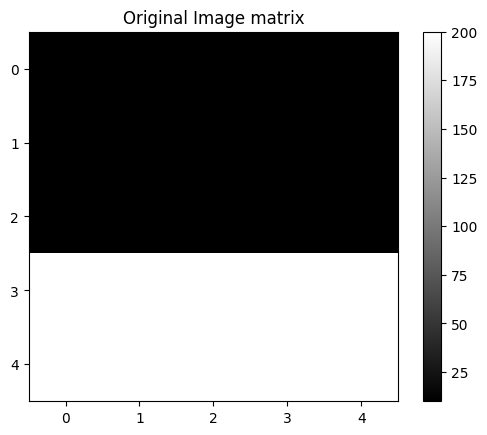

Final Gradient Magnitude Matrix:
[[   0.           0.           0.       ]
 [1074.8023074 1074.8023074 1074.8023074]
 [1074.8023074 1074.8023074 1074.8023074]]


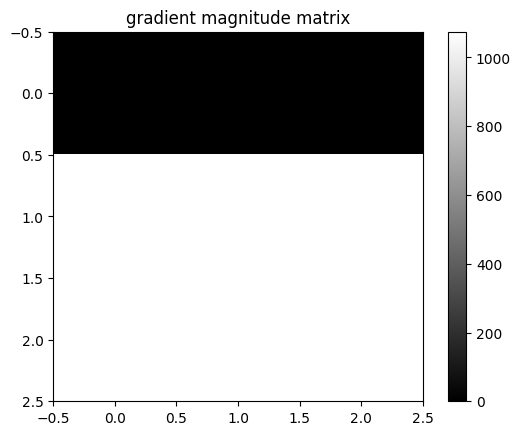


Thresholded Edge Map (T=100):
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


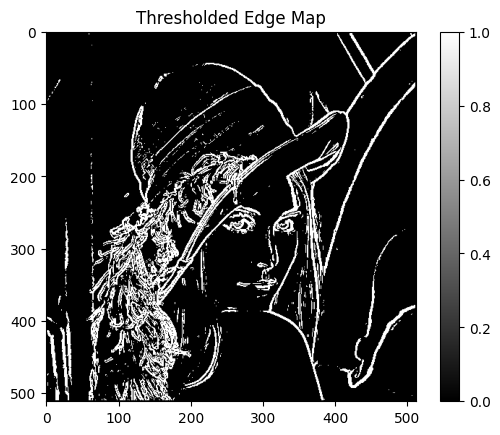

In [10]:
print(arr) 
plt.imshow(arr, cmap='gray')
plt.title('Original Image matrix')
plt.colorbar()
plt.show()   
print("Final Gradient Magnitude Matrix:")
print(output)
plt.imshow(output, cmap='gray')
plt.title('gradient magnitude matrix')
plt.colorbar()
plt.show()
print("\nThresholded Edge Map (T=100):" )
print(edge_map)
plt.imshow(edge_map, cmap='gray')
plt.title('Thresholded Edge Map')
plt.colorbar()
plt.show()  

## without padding

In [11]:
import numpy as np

def sobel_without_padding(image):
    """
    Applies the Sobel operator to a 2D grayscale image without padding.
    
    Parameters:
        image (numpy.ndarray): A 2D array representing a grayscale image.
        
    Returns:
        numpy.ndarray: The edge-detected image, dimensions reduced by 2.
    """
    # Ensure the image is 2D (grayscale)
    if len(image.shape) != 2:
        raise ValueError("Image must be a 2D grayscale array.")

    height, width = image.shape

    # Define the 3x3 Sobel kernels
    Kx = np.array([[-1, 0, 1],
                   [-2, 0, 2],
                   [-1, 0, 1]])

    Ky = np.array([[-1, -2, -1],
                   [ 0,  0,  0],
                   [ 1,  2,  1]])

    # Calculate output dimensions (No padding means we lose a 1-pixel border on all sides)
    out_height = height - 2
    out_width = width - 2

    # Initialize output arrays
    Gx = np.zeros((out_height, out_width))
    Gy = np.zeros((out_height, out_width))

    # Slide the 3x3 window over the image
    for i in range(out_height):
        for j in range(out_width):
            # Extract the 3x3 local region from the image
            region = image[i:i+3, j:j+3]

            # Element-wise multiplication and sum
            Gx[i, j] = np.sum(region * Kx)
            Gy[i, j] = np.sum(region * Ky)

    # Calculate the overall gradient magnitude
    magnitude = np.sqrt(Gx**2 + Gy**2)

    # Normalize the result to a 0-255 range so it can be viewed as an image
    magnitude = (magnitude / np.max(magnitude)) * 255
    
    return magnitude.astype(np.uint8)

# --- Example Usage ---
if __name__ == "__main__":
    # Create a dummy 5x5 image (e.g., a dark image with a bright center)
    sample_image = np.array([[ 10,  10,  10,  10,  10],
                             [ 10,  50, 100,  50,  10],
                             [ 10, 100, 200, 100,  10],
                             [ 10,  50, 100,  50,  10],
                             [ 10,  10,  10,  10,  10]], dtype=float)

    print(f"Original Image Shape: {sample_image.shape}")
    
    edges = sobel_without_padding(sample_image)
    
    print(f"Edge Image Shape (No Padding): {edges.shape}")
    print("\nResulting Edge Magnitude Matrix:")
    print(edges)

Original Image Shape: (5, 5)
Edge Image Shape (No Padding): (3, 3)

Resulting Edge Magnitude Matrix:
[[238 255 238]
 [255   0 255]
 [238 255 238]]


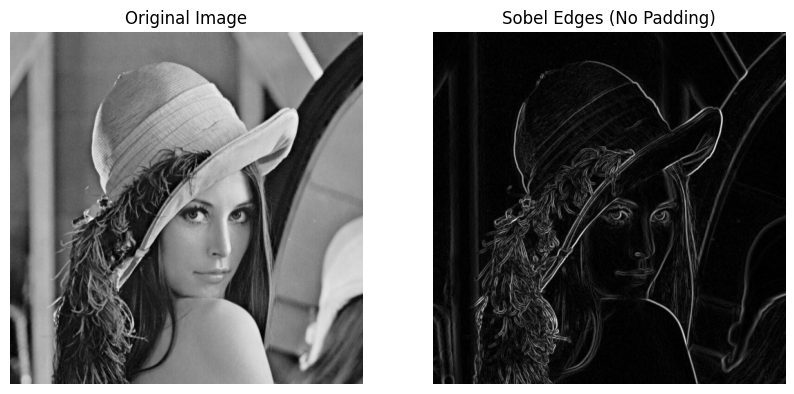

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread(r'C:\BDA\digital image processing\Dip_class\dip_img\lena_image.png',0)


# Sobel Kernels
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]])

sobel_y = np.array([[-1, -2, -1],
                    [0, 0, 0],
                    [1, 2, 1]])

# Get image dimensions
height, width = img.shape

# Define kernel size
kernel_k = sobel_x.shape[0]
offset = kernel_k // 2

# Output images will be smaller since no padding is applied
output_height = height - 2 * offset
output_width = width - 2 * offset

gx_no_pad = np.zeros((output_height, output_width), dtype=float)
gy_no_pad = np.zeros((output_height, output_width), dtype=float)

# Convolution without padding
for i in range(offset, height - offset):
    for j in range(offset, width - offset):
        # Extract the region of interest from the original image
        region = img[i - offset : i + offset + 1, j - offset : j + offset + 1]

        # Perform convolution for x and y gradients
        gx_no_pad[i - offset, j - offset] = np.sum(region * sobel_x)
        gy_no_pad[i - offset, j - offset] = np.sum(region * sobel_y)

# Gradient magnitude
edges_no_pad = np.sqrt(gx_no_pad**2 + gy_no_pad**2)

# Normalize the edge magnitude to 0-255 range
if np.max(edges_no_pad) > 0:
    edges_no_pad = np.uint8(255 * (edges_no_pad / np.max(edges_no_pad)))
else:
    edges_no_pad = np.zeros_like(edges_no_pad, dtype=np.uint8)

# Display results
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Sobel Edges (No Padding)")
plt.imshow(edges_no_pad, cmap='gray')
plt.axis('off')
plt.show()

## **With Padding**

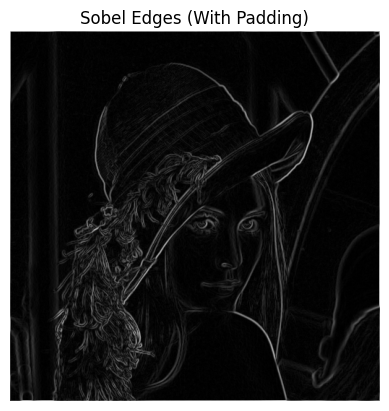

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
img = cv2.imread(r'C:\BDA\digital image processing\Dip_class\dip_img\lena_image.png', 0)

# Sobel Kernels
sobel_x = np.array([[-1,0,1],
                    [-2,0,2],
                    [-1,0,1]])

sobel_y = np.array([[-1,-2,-1],
                    [0,0,0],
                    [1,2,1]])

# Padding image
padded = np.pad(img, ((1,1),(1,1)), mode='constant')

# Output images
gx = np.zeros_like(img, dtype=float)
gy = np.zeros_like(img, dtype=float)

# Convolution
for i in range(img.shape[0]):
    for j in range(img.shape[1]):
        region = padded[i:i+3, j:j+3]
        gx[i,j] = np.sum(region * sobel_x)
        gy[i,j] = np.sum(region * sobel_y)

# Gradient magnitude
edges = np.sqrt(gx**2 + gy**2)
# Read image
plt.imshow(edges, cmap='gray')
plt.title('Sobel Edges (With Padding)')
plt.axis('off')
plt.show()

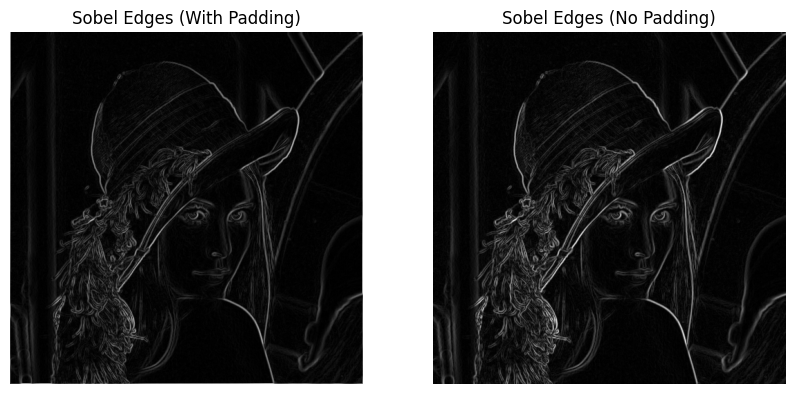

In [14]:
# without padding and with padding
# Display results
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Sobel Edges (With Padding)")
plt.imshow(edges, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Sobel Edges (No Padding)")
plt.imshow(edges_no_pad, cmap='gray')
plt.axis('off')
plt.show()